# Exploratory data analysis of the dataset
This notebook provides an initial exploratory data analysis of the 2011 UK Census dataset (https://www.ons.gov.uk/census/2011census/2011censusdata/censusmicrodata/microdatateachingfile). It consist of 17 categorical variables. The "other values" are indicated as -9. They don't correspond to missing values, but to other categories, all regrouped into the same one.

  
For more information about the variables, see https://www.ons.gov.uk/census/2011census/2011censusdata/censusmicrodata/microdatateachingfile/variablelist. 

## Imports and other setup

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path
sys.path.append('..')

import matplotlib.pyplot as plt

# ml efficiency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# custom
from tools.utils import *
from tools.eda import *
from tools.features_analysis import *
from tools.synthetic_evaluation.ml_utility import run_ml_utility_census


In [2]:
os.chdir('..')

In [3]:
DATA_FOLDER = Path('./data')
OUTPUT_FOLDER = Path('./generated/eda')
NAN_SYMBOLE = -9

## Import dataset

In [ ]:
census = load_census(DATA_FOLDER/'census.csv')
census.head()

,region,residence_type,family_composition,population_base,sex,age,marital_status,student,country_of_birth,health,ethnic_group,religion,economic_activity,occupation,industry,hours_worked_per_week,approximated_social_grade
0,E12000001,H,2,1,2,6,2,2,1,2,1,2,5,8,2,-9,4
1,E12000001,H,5,1,1,4,1,2,1,1,1,2,1,8,6,4,3
2,E12000001,H,3,1,2,4,1,2,1,1,1,1,1,6,11,3,4
3,E12000001,H,3,1,2,2,1,2,1,2,1,2,1,7,7,3,2
4,E12000001,H,3,1,1,5,4,2,1,1,1,2,1,1,4,3,2


## Profiling report
The profiling report is practical to get a quick overview of the dataset distributions and correlation, in a pretty HTML format.
🟠 The number of missing values generated in the report is not correct. See below for the correct number.

In [5]:
report = generate_census_profiling_report(census, OUTPUT_FOLDER, 'census_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Dataset overall statistics

In [6]:
get_overall_stats(census, NAN_SYMBOLE)

/Users/taapeco3/Documents/master_thesis/dev/colin-pelletier/privacy/tools/eda.py:206: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  stats['n_na_rows'] = len(df)-len(df.replace(nan_value, np.nan).dropna())


,n_rows,n_cols,n_na_rows,na_rows_%,n_duplicates,duplicates_%
dataset,569741,17,304572,53.46,232718,40.85


## Univariate analysis

### Quantitative

In [ ]:
get_categorical_features_stats(census, is_replace_na=True)

,region,residence_type,family_composition,population_base,sex,age,marital_status,student,country_of_birth,health,ethnic_group,religion,economic_activity,occupation,industry,hours_worked_per_week,approximated_social_grade
count,569741,569741,569741,569741,569741,569741,569741,569741,569741,569741,569741,569741,569741,569741,569741,569741,569741
unique,10,2,7,3,2,8,5,2,3,6,6,10,10,10,13,5,5
top,E12000008,H,2,1,2,1,1,2,1,1,1,2,1,-9,-9,-9,2
top_freq,88084,559087,300962,561040,289172,106832,270999,443204,485645,264971,483477,333481,216025,149984,149984,302321,159642
top_%,15.46,98.13,52.82,98.47,50.75,18.75,47.57,77.79,85.24,46.51,84.86,58.53,37.92,26.32,26.32,53.06,28.02


### Qualitative

Running analysis...
Comparing Hist Plots:


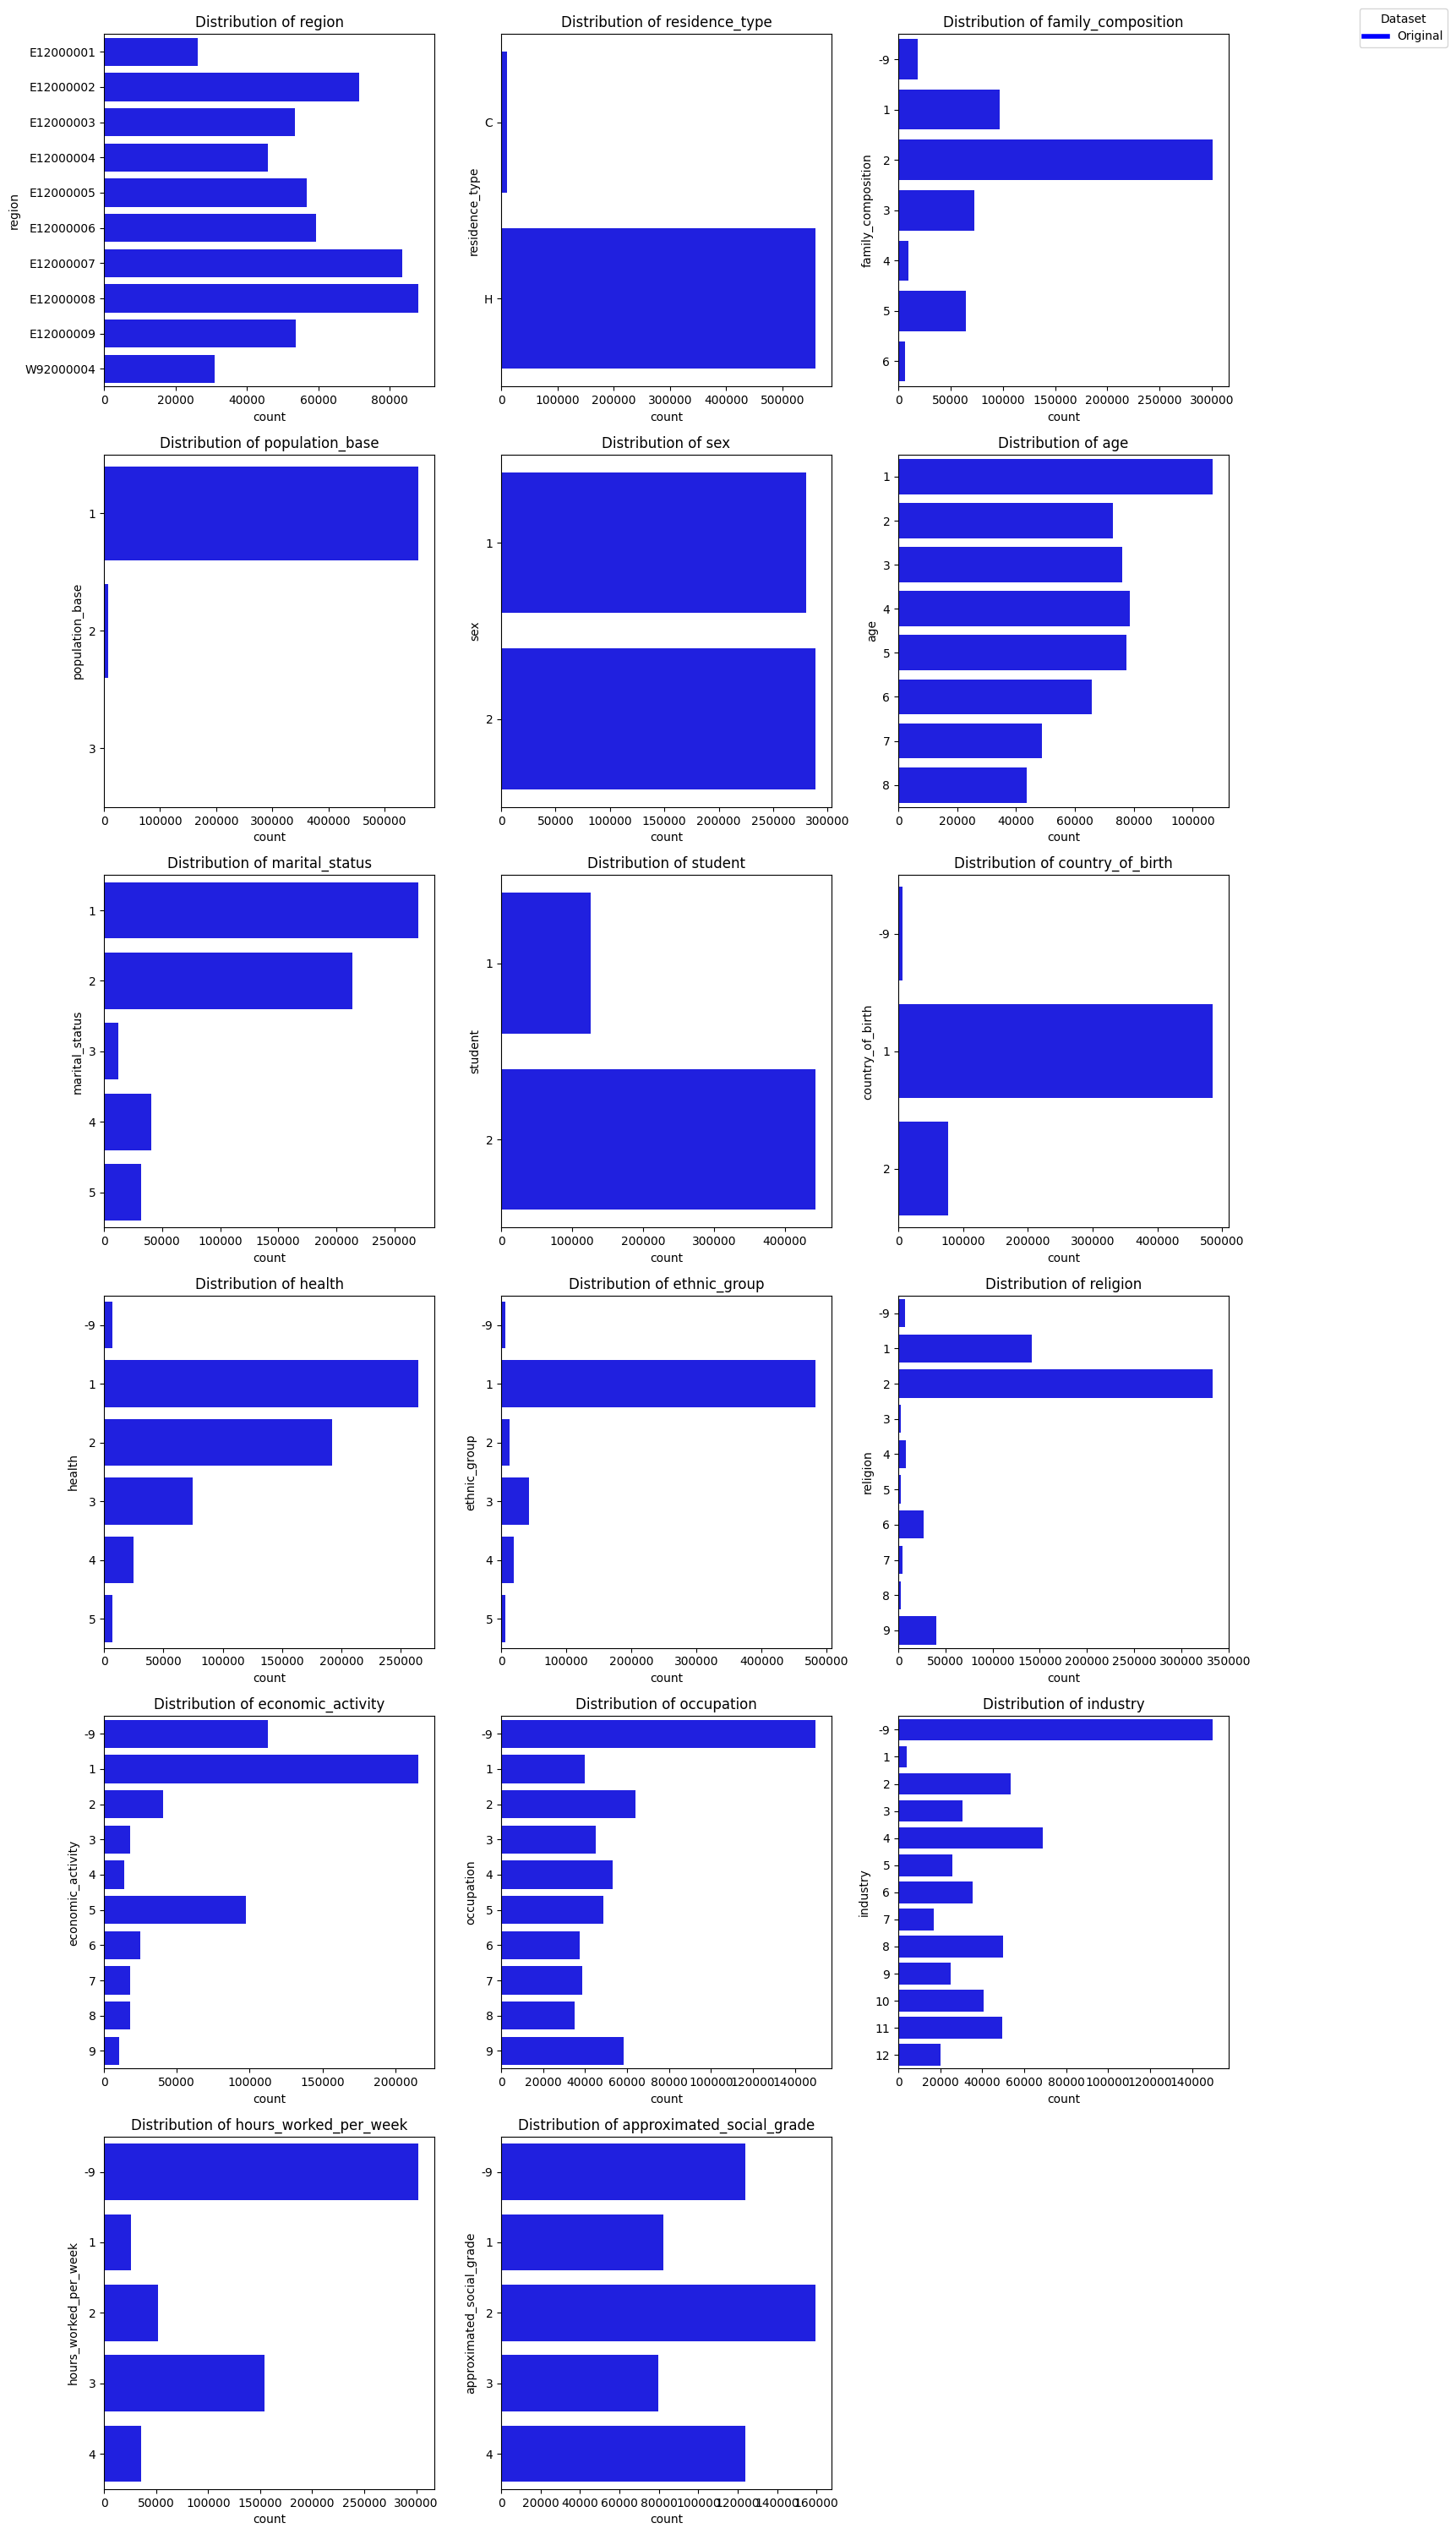

Correlations


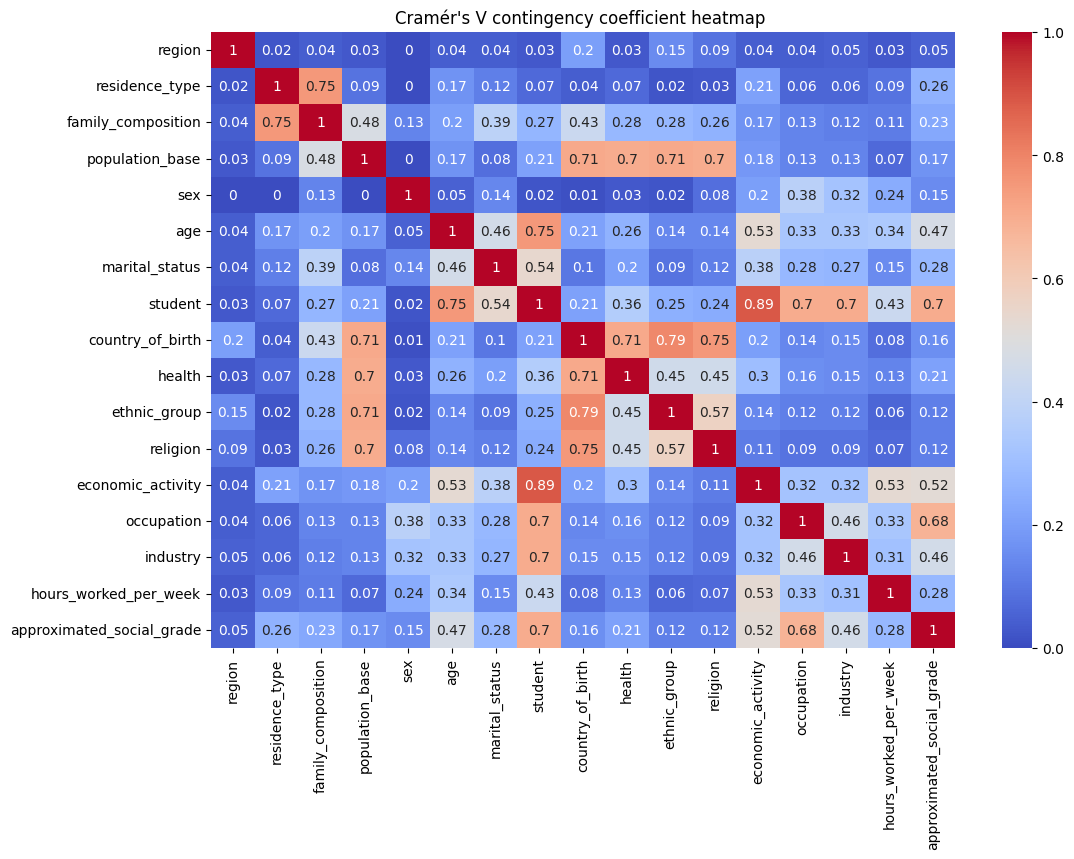

Analysis completed!


In [ ]:
%matplotlib inline
run_analysis(census, numerical_features=[], categorical_features=census.columns)

## ML performances
We will now define the pipeline to run a machine learning model on the Adults dataset. This will particulary useful to compute the ML utility of generative models.

In [ ]:
RANDOM_STATE = 42
target_col = 'sex'
X_train, X_test = train_test_split(census, test_size=0.2, random_state=RANDOM_STATE)

In [ ]:
from tools.synthetic_evaluation.ml_utility import run_ml_utility
target_column = 'sex'
categorical_features = [col for col in census.columns if col != target_column]
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)

target_distr, clf_res_train, clf_res_test = run_ml_utility(
        df_train=X_train, 
        df_test=X_test,  
        numerical_features=[],
        categorical_features=categorical_features,
        target_column=target_column,
        clf=clf,
        round_decimals=2,
        verbose=True)

model_results = pd.DataFrame({'train f1-score': clf_res_train.loc['1']['f1-score'], 
                                'test f1-score': clf_res_test.loc['1']['f1-score'],}, index=['Original'])

Train F1 Score: 0.73
Cross validation mean F1 Score: 0.73 (std 0.00)
Test F1 Score: 0.73
Test Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.80      0.73     56359
           2       0.76      0.62      0.68     57590

    accuracy                           0.71    113949
   macro avg       0.72      0.71      0.71    113949
weighted avg       0.72      0.71      0.71    113949

